In [1]:
import json
import math
import folium
import networkx as nx
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

# --- Config ---
DATA_PATH = "/Volumes/Extreme SSD/SUMO Data/station_information.json"
CSV_2025  = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2025_010203040506070809101112.csv"
CSV_2026  = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2026_01020304.csv"

LONGUEUIL_CENTER = (45.5219, -73.4645)
RADIUS_KM = 6

bounding_box = [-73.62368, 45.44845, -73.43142, 45.53822]


## All BIXI stations loaded from station_information.json

In [2]:
with open(DATA_PATH) as f:
    raw = json.load(f)

stations = [
    s for s in raw["data"]["stations"]
    if s["lat"] != 0 and s["lon"] != 0
]

print(f"{len(stations)} valid stations loaded")

1059 valid stations loaded


In [3]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]

bounds = [[min(lats), min(lons)], [max(lats), max(lons)]]

m = folium.Map(tiles="CartoDB positron")
m.fit_bounds(bounds, padding=(24, 24))

for s in stations:
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=4,
        color="#e63e2a",
        fill=True,
        fill_color="#e63e2a",
        fill_opacity=0.85,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>{s['name']}</b><br>ID: {s['station_id']}<br>Capacity: {s['capacity']}",
            sticky=False,
        ),
    ).add_to(m)

m

## Rive-Sud (South Shore) Stations
Stations within a set radius of central Longueuil, used as a proxy for the south shore cluster.

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

rive_sud = [
    s for s in stations
    if haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], s["lat"], s["lon"]) <= RADIUS_KM
]

print(f"Stations within {RADIUS_KM} km of Longueuil center: {len(rive_sud)}")
for s in sorted(rive_sud, key=lambda x: haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], x["lat"], x["lon"])):
    dist = haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], s["lat"], s["lon"])
    print(f"  {dist:4.1f} km  [{s['station_id']:>4}] {s['name']}")


Stations within 6 km of Longueuil center: 81
   0.1 km  [1035] Faribault / de Chambly
   0.6 km  [1039] des Ormeaux / Mathieu
   0.6 km  [1053] Montarville / Beaubien
   0.8 km  [1040] Sacré-Coeur / Gamache
   0.9 km  [1036] Darveau / de Lyon
   1.0 km  [1160] Racicot / Roberval
   1.2 km  [1034] Roland-Therrien / Jacques-Cartier
   1.3 km  [1175] Parc Lecavalier (McGill)
   1.4 km  [1177] Parc Marquette (Nobert)
   1.5 km  [1046] Parc Gentilly Ouest (Belcourt / Bagot)
   1.5 km  [ 881] Parc Laurier (Laurier / Dubuc)
   1.5 km  [1041] Ste-Hélène / Papineau
   1.7 km  [ 879] Hôpital Pierre-Boucher (Jacques-Cartier / Bourdon)
   1.8 km  [1172] Roland-Therrien / Roberval /
   1.8 km  [1037] Roland-Therrien / Antoinette-Robidoux
   1.8 km  [1162] Curé-Poirier / Joliette
   1.9 km  [1159] Parc Belcourt (Bariteau)
   1.9 km  [1043] Cuvillier / de Chambly
   2.0 km  [1166] Curé-Poirier / Roland-Therrien
   2.1 km  [ 898] Beauregard / La Salle
   2.1 km  [ 880] Lamarre / Lavallée
   2.2 km  [ 

In [5]:
rive_sud_ids = {s["station_id"] for s in rive_sud}

m2 = folium.Map(tiles="CartoDB positron")

for s in stations:
    is_rs = s["station_id"] in rive_sud_ids
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=5 if is_rs else 3,
        color="#0057b8" if is_rs else "#aaaaaa",
        fill=True,
        fill_color="#0057b8" if is_rs else "#cccccc",
        fill_opacity=0.9 if is_rs else 0.5,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>{s['name']}</b><br>ID: {s['station_id']}<br>Capacity: {s['capacity']}"
            + (" <i>(Rive-Sud)</i>" if is_rs else ""),
            sticky=False,
        ),
    ).add_to(m2)

# Draw the radius circle
folium.Circle(
    location=LONGUEUIL_CENTER,
    radius=RADIUS_KM * 1000,
    color="#0057b8",
    fill=False,
    weight=1.5,
    dash_array="6",
    tooltip=f"Longueuil center, {RADIUS_KM} km radius",
).add_to(m2)

# Fit to Longueuil area
all_lats = [s["lat"] for s in stations]
all_lons = [s["lon"] for s in stations]
m2.fit_bounds([[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]], padding=(24, 24))
m2

In [6]:
G_bike = ox.graph.graph_from_bbox(bounding_box, network_type="bike")
G_walk = ox.graph.graph_from_bbox(bounding_box, network_type="walk")
G = nx.compose(G_bike, G_walk)


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_44025/49112894.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


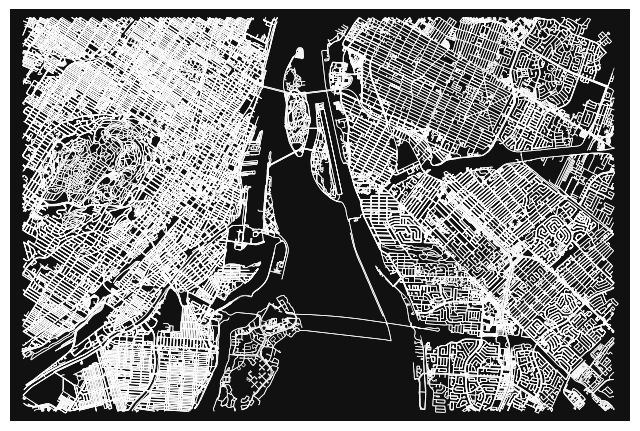

In [7]:
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
fig.show()

## Trip Heatmap on Longueuil Bike Network
Rides from the 2025 dataset whose start **or** end station is a Rive-Sud station (m2), routed as shortest paths on G and displayed as a heatmap. Shortest paths are computed once per unique OD node pair. (Shortest Path = Dijstra's algorithm)

In [8]:
rive_sud_names = {s["name"] for s in rive_sud}

cols = ["STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE",
        "ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"]

def filter_csv(path, names_set, chunksize=200_000):
    """Read CSV in chunks, keep only rows touching a station in names_set.
    Returns (filtered_df, total_row_count)."""
    chunks = []
    total = 0
    for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize):
        chunk = chunk.dropna()
        total += len(chunk)
        mask = chunk["STARTSTATIONNAME"].isin(names_set) | chunk["ENDSTATIONNAME"].isin(names_set)
        filtered = chunk[mask]
        if not filtered.empty:
            chunks.append(filtered)
    df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=cols)
    return df, total

print("Loading 2025…")
trips_2025, total_2025 = filter_csv(CSV_2025, rive_sud_names)
print(f"  {len(trips_2025):,} matching trips")

# print("Loading 2026…")
# trips_2026, total_2026 = filter_csv(CSV_2026, rive_sud_names)
# print(f"  {len(trips_2026):,} matching trips")

# trips = pd.concat([trips_2025, trips_2026], ignore_index=True)
# total = total_2025 + total_2026
# print(f"Combined: {len(trips):,} trips")
trips = trips_2025
total_trips = total_2025

Loading 2025…


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_44025/3099396295.py:11: DtypeWarning: Columns (0: ENDSTATIONLATITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize):


  117,945 matching trips


In [9]:
filtered_trips = len(trips)
pct = filtered_trips / total_trips * 100

print(f"Total trips:         {total_trips:>10,}")
print(f"Filtered trips:      {filtered_trips:>10,}")
print(f"Representation:      {pct:>9.2f}%")

Total trips:         14,197,540
Filtered trips:         117,945
Representation:           0.83%


#### Shortest path implementation with ALT

In [10]:
def precompute_ALT(graph, n_landmarks=16, weight="length", seed=42):
    """Select landmarks via farthest-point sampling and precompute forward/backward distances.

    Returns (landmarks, dist_from, dist_to):
      dist_from[L][v]  shortest distance from landmark L to node v (forward Dijkstra)
      dist_to[L][v]    shortest distance from node v to landmark L (reverse-graph Dijkstra)
    """
    import random
    rng = random.Random(seed)
    nodes = list(graph.nodes())
    G_rev = graph.reverse(copy=False)
    dist_from, dist_to, landmarks = {}, {}, []

    first = rng.choice(nodes)
    landmarks.append(first)
    dist_from[first] = nx.single_source_dijkstra_path_length(graph, first, weight=weight)
    dist_to[first]   = nx.single_source_dijkstra_path_length(G_rev,  first, weight=weight)
    print(f"  landmark 1/{n_landmarks}: {first}")

    for i in range(1, n_landmarks):
        # Farthest-point sampling: next landmark maximises min-dist to any current landmark
        best, best_d = None, -1.0
        for v in nodes:
            d = min(dist_from[L].get(v, float('inf')) for L in landmarks)
            if d > best_d:
                best_d, best = d, v
        landmarks.append(best)
        dist_from[best] = nx.single_source_dijkstra_path_length(graph, best, weight=weight)
        dist_to[best]   = nx.single_source_dijkstra_path_length(G_rev,  best, weight=weight)
        print(f"  landmark {i+1}/{n_landmarks}: {best}  ({best_d:.0f} m from nearest landmark)")

    return landmarks, dist_from, dist_to


def make_ALT_heuristic(landmarks, dist_from, dist_to):
    """Return an admissible lower-bound heuristic h(u, t) using the triangle inequality.

    For each landmark L:
      dist(u→t) ≥ dist(L→t) − dist(L→u)    [forward triangle]
      dist(u→t) ≥ dist(u→L) − dist(t→L)    [backward triangle]
    h is the max non-negative bound across all landmarks.
    """
    def h(u, t):
        best = 0.0
        for L in landmarks:
            du = dist_from[L].get(u, float('inf'))
            dt = dist_from[L].get(t, float('inf'))
            if du < float('inf') and dt < float('inf'):
                best = max(best, dt - du)
            tu = dist_to[L].get(u, float('inf'))
            tt = dist_to[L].get(t, float('inf'))
            if tu < float('inf') and tt < float('inf'):
                best = max(best, tu - tt)
        return best
    return h


def shortest_path_ALT(graph, origin, destination, heuristic_fn, weight="length"):
    """A* shortest path guided by the precomputed ALT heuristic."""
    try:
        return nx.astar_path(graph, origin, destination, heuristic=heuristic_fn, weight=weight)
    except nx.NetworkXNoPath:
        return None

In [11]:
print("Precomputing ALT landmarks (one-time cost, ~30–60 s)…")
landmarks, dist_from, dist_to = precompute_ALT(G, n_landmarks=16)
alt_heuristic = make_ALT_heuristic(landmarks, dist_from, dist_to)
print(f"\nDone — {len(landmarks)} landmarks ready.")

Precomputing ALT landmarks (one-time cost, ~30–60 s)…
  landmark 1/16: 6721030544
  landmark 2/16: 209473656  (inf m from nearest landmark)
  landmark 3/16: 213573037  (inf m from nearest landmark)
  landmark 4/16: 213955306  (inf m from nearest landmark)
  landmark 5/16: 262070652  (inf m from nearest landmark)
  landmark 6/16: 310655888  (inf m from nearest landmark)
  landmark 7/16: 1188375701  (inf m from nearest landmark)
  landmark 8/16: 1329114145  (inf m from nearest landmark)
  landmark 9/16: 2187165004  (inf m from nearest landmark)
  landmark 10/16: 2188531362  (inf m from nearest landmark)
  landmark 11/16: 3196460289  (inf m from nearest landmark)
  landmark 12/16: 3389786834  (inf m from nearest landmark)
  landmark 13/16: 3711199625  (inf m from nearest landmark)
  landmark 14/16: 4321538865  (inf m from nearest landmark)
  landmark 15/16: 4321538866  (inf m from nearest landmark)
  landmark 16/16: 4908928929  (inf m from nearest landmark)

Done — 16 landmarks ready.


#### Shortest path implementation with A*

In [12]:
def shortest_path_Astar(graph, origin, destination, weight="length"):
    """Shortest path using A* algorithm."""
    def heuristic(u, v):
        lu, lv = graph.nodes[u], graph.nodes[v]
        return ox.distance.great_circle(lu['y'], lu['x'], lv['y'],lv['x'])
    try:
        return nx.astar_path(graph, origin, destination, heuristic=heuristic, weight=weight)
    except nx.NetworkXNoPath:
        return None


In [13]:
# --- Step 1: build station-name → (lat, lon) from the filtered trips ---
station_coords = {}
for col_name, col_lat, col_lon in [
    ("STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE"),
    ("ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"),
]:
    for _, row in trips[[col_name, col_lat, col_lon]].drop_duplicates(col_name).iterrows():
        station_coords[row[col_name]] = (row[col_lat], row[col_lon])

# --- Step 2: bulk nearest-node lookup (one call, all stations at once) ---
names  = list(station_coords)
lats   = [station_coords[n][0] for n in names]
lons   = [station_coords[n][1] for n in names]
nodes  = ox.distance.nearest_nodes(G, lons, lats)
station_to_node = dict(zip(names, nodes))

# --- Step 3: count trips per unique (src_node, dst_node) pair ---
pair_counts = defaultdict(int)
for _, row in trips.iterrows():
    src = station_to_node.get(row["STARTSTATIONNAME"])
    dst = station_to_node.get(row["ENDSTATIONNAME"])
    if src and dst and src != dst:
        pair_counts[(src, dst)] += 1

print(f"Unique OD node pairs: {len(pair_counts):,}")

Unique OD node pairs: 11,477


#### Algorithm comparison: Dijkstra vs A* vs ALT

In [14]:
import time

def _dijkstra(src, dst):
    try:
        return nx.dijkstra_path(G, src, dst, weight="length")
    except nx.NetworkXNoPath:
        return None

algorithms = {
    "Dijkstra": _dijkstra,
    "A*":       lambda src, dst: shortest_path_Astar(G, src, dst),
    "ALT":      lambda src, dst: shortest_path_ALT(G, src, dst, alt_heuristic),
}

algo_results = {}
for name, fn in algorithms.items():
    edge_load = defaultdict(int)
    skipped = 0
    t0 = time.perf_counter()
    for (src, dst), count in pair_counts.items():
        path = fn(src, dst)
        if path is None:
            skipped += 1
        else:
            for u, v in zip(path[:-1], path[1:]):
                edge_load[(u, v)] += count
    elapsed = time.perf_counter() - t0
    algo_results[name] = {"edge_load": edge_load, "elapsed": elapsed, "skipped": skipped}
    print(f"{name:10s}  {elapsed:7.1f} s  |  edges loaded: {len(edge_load):,}  |  skipped: {skipped}")

# Sanity-check: all three should produce identical edge loads (same optimal paths)
loads = [frozenset(r["edge_load"].items()) for r in algo_results.values()]
print(f"\nEdge loads identical across algorithms: {len(set(loads)) == 1}")

Dijkstra     1382.6 s  |  edges loaded: 31,645  |  skipped: 0
A*            598.2 s  |  edges loaded: 31,645  |  skipped: 0
ALT           698.6 s  |  edges loaded: 31,670  |  skipped: 0

Edge loads identical across algorithms: False


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_44025/848500453.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


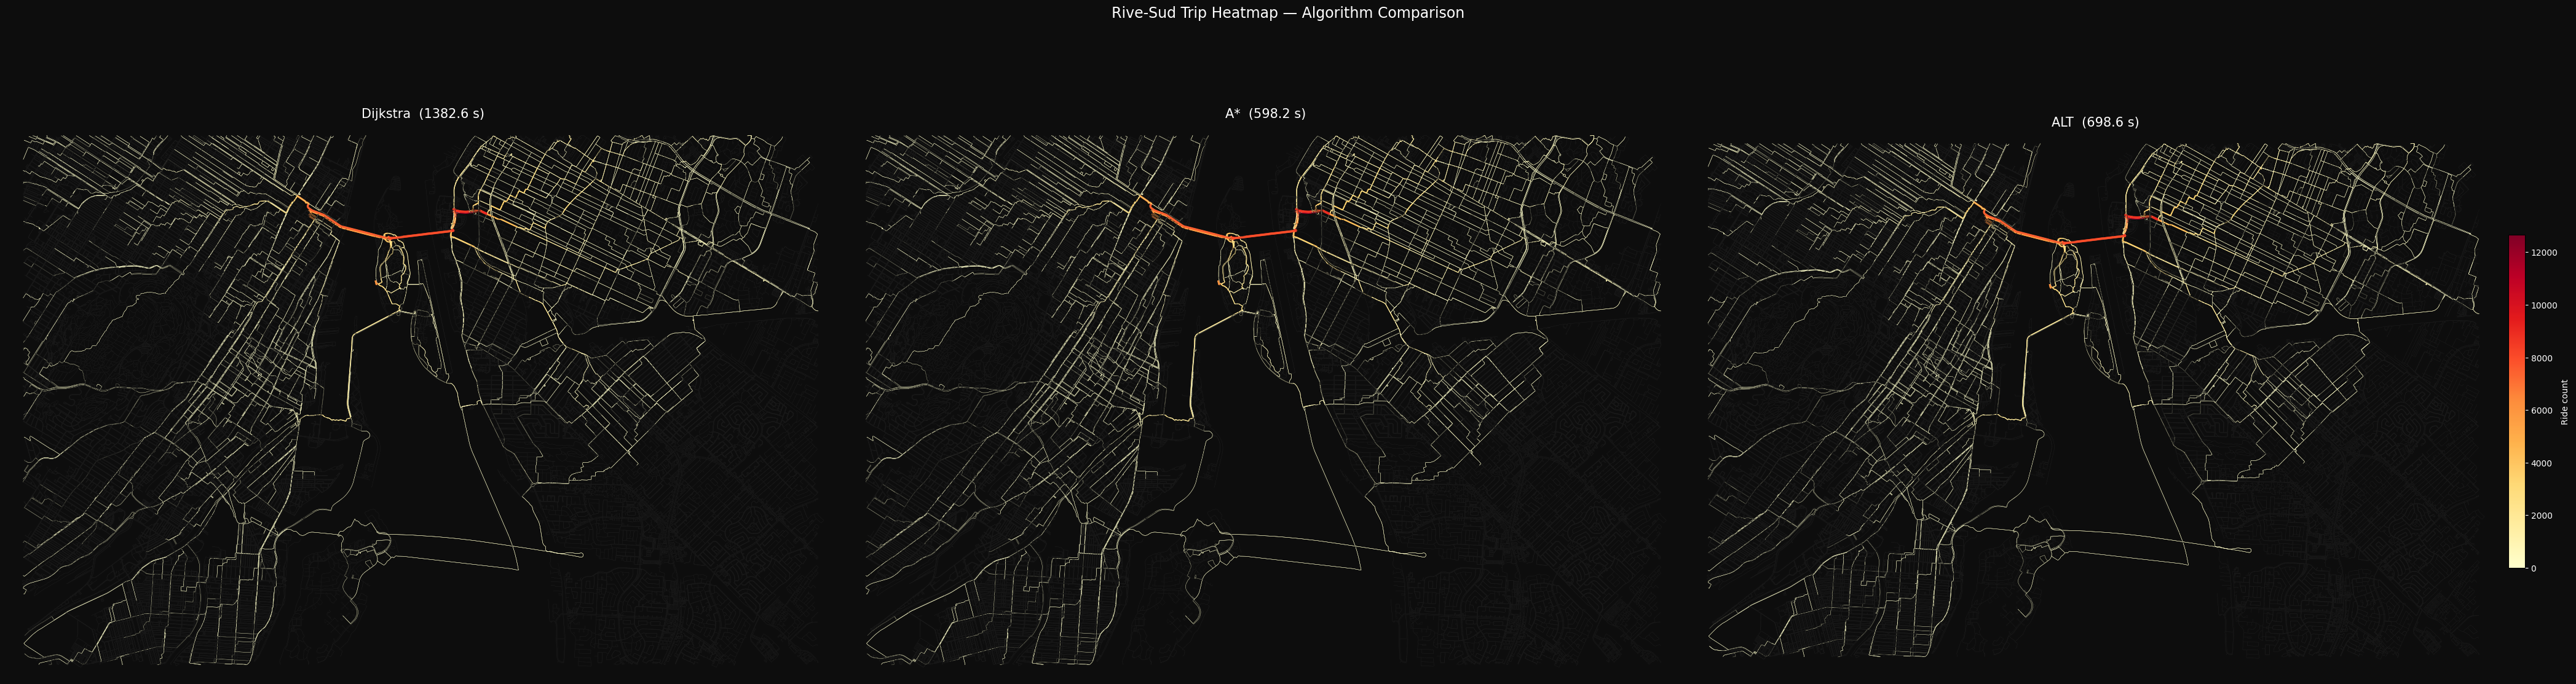

In [16]:
cmap          = plt.cm.YlOrRd
no_load_color = mcolors.to_rgba("#1a1a1a")

global_max = max(max(r["edge_load"].values()) for r in algo_results.values() if r["edge_load"])

fig, axes = plt.subplots(1, 3, figsize=(42, 12))
fig.patch.set_facecolor("#0d0d0d")
for ax in axes:
    ax.set_facecolor("#0d0d0d")

for ax, (name, res) in zip(axes, algo_results.items()):
    edge_load = res["edge_load"]

    edge_colors, edge_widths = [], []
    for u, v, _ in G.edges(keys=True):
        load = edge_load.get((u, v), 0)
        norm = load / global_max
        edge_colors.append(cmap(norm) if load > 0 else no_load_color)
        edge_widths.append(0.3 + 3.5 * norm)

    ox.plot.plot_graph(
        G, ax=ax,
        edge_color=edge_colors,
        edge_linewidth=edge_widths,
        node_size=0,
        bgcolor="#0d0d0d",
        show=False, close=False,
    )
    ax.set_title(f"{name}  ({res['elapsed']:.1f} s)", color="white", fontsize=15, pad=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, global_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], fraction=0.02, pad=0.01)
cbar.set_label("Ride count", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

fig.suptitle("Rive-Sud Trip Heatmap — Algorithm Comparison", color="white", fontsize=17, y=1.02)
fig.tight_layout()
fig.show()